### Gym Gridworld - RL

In [1]:
import gymnasium
from gymnasium.wrappers import FlattenObservation, HumanRendering
import numpy as np
from tqdm import tqdm 

from src.environments.gridworld import GridWorldEnv, DiscreteGridWorldWrapper, Cells, Actions
from src.agents.QLambdaLearner import QLambdaLearningAgent
from src.solvers.GridWorldSolver import GridWorldSolver
from src.utility.SessionRunner import play_game

### Learning how to set up the environment

Cound create environment directly like this:  
```py
env = GridWorldEnv()
``` 
However, the environment is registered in gymnasium in the __init__.py files in *environments*, so it can also be created via *gymnasium.make*

In [ ]:
# Custom grid world layout
huge_grid = np.array((
    [0,0,0,0,0,0,3,3,3,3,3,3,3,3,3,3,3,3,0,0,0,0,0,0,0,0,0,3,0,0,0,0],
    [0,0,0,0,0,0,3,0,3,3,3,3,3,0,0,0,0,3,0,0,0,0,0,0,0,3,0,0,0,3,0,0],
    [0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,3,0,3,0,3,0,0],
    [0,0,0,0,0,0,3,0,0,0,0,0,3,0,0,3,3,3,0,0,0,0,0,0,0,3,3,3,3,3,0,0],
    [0,0,0,0,0,0,3,3,3,3,3,0,3,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,3,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,3,3,3,3,3,0,0,0,0,0,0,0,3,0,0],
    [0,0,0,0,0,0,0,3,3,3,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0],
    [0,0,0,0,0,0,0,3,0,3,0,0,3,0,3,3,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0],
    [0,0,0,0,0,0,0,3,0,3,3,3,3,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0],
    [0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0],
    [0,0,0,0,0,0,0,3,3,3,3,3,3,3,3,3,0,0,3,3,3,3,3,0,0,0,0,0,0,3,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,3,3,3,3,3,0,0,0,3,3,3,3,0,0],
    [3,3,3,3,0,3,3,3,3,3,3,3,3,3,0,3,0,0,3,3,3,3,3,0,0,0,3,0,0,0,0,0],
    [3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,2,2,3,3,3,3,3,0,0,0,3,0,0,0,0,0],
    [3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,0,0,3,3,3,3,3,0,0,0,3,0,0,1,0,0],
    [3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,3,3,3,3,3,0,0,0,3,0,0,0,0,0],
    [3,3,0,3,3,0,3,3,3,0,3,3,3,3,3,3,0,0,0,0,0,0,0,0,0,0,3,3,3,3,3,0],
    [0,0,0,0,0,0,0,3,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,2,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0]
))

# Custom reward structure
huge_world_reward: dict = {
    Cells.TILE.value: -0.5, # step on regular cell
    Cells.TARGET.value: 1000.0, # good ending
    Cells.PITFALL.value: -100.0, # bad ending
    Cells.WALL.value: -2.0 # hit obstacle
} # Adjusting the rewards can be considered hyperparameter tuning - we can help the mode converge faster by representing the reward structure better

# Environment
env = gymnasium.make(id="gymnasium_env/GridWorld-v0", grid=huge_grid, reward=huge_world_reward, render_mode=None)
# or env = GridWorldEnv(grid=huge_grid, reward=huge_world_reward, render_mode=None)

In [3]:
env.observation_space

Dict('agent': Box(0, [19 32], (2,), int64))

In [5]:
obs, info = env.reset()
print("Observation: ", obs)
print("Info: ", info)

Observation:  {'agent': array([11,  4])}
Info:  {'distance': np.float64(28.0)}


In [7]:
# Wrappers can be used on the env for various purposes, like flattening observations into a single array
wrapped_env = FlattenObservation(env)
wrapped_env.observation_space

Box(0, [19 32], (2,), int64)

This is particularly useful when working with algorithms that expect specific input formats (like neural networks that need 1D arrays instead of dictionaries).

In [ ]:
obs, info = wrapped_env.reset()
print("Observation: ", obs)

Observation:  [ 4 15]


: 

### Training Agent

In [2]:
# Custom grid world layout
huge_grid = np.array((
    [0,0,0,0,0,0,3,3,3,3,3,3,3,3,3,3,3,3,0,0,0,0,0,0,0,0,0,3,0,0,0,0],
    [0,0,0,0,0,0,3,0,3,3,3,3,3,0,0,0,0,3,0,0,0,0,0,0,0,3,0,0,0,3,0,0],
    [0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,3,0,3,0,3,0,0],
    [0,0,0,0,0,0,3,0,0,0,0,0,3,0,0,3,3,3,0,0,0,0,0,0,0,3,3,3,3,3,0,0],
    [0,0,0,0,0,0,3,3,3,3,3,0,3,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,3,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,3,3,3,3,3,0,0,0,0,0,0,0,3,0,0],
    [0,0,0,0,0,0,0,3,3,3,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0],
    [0,0,0,0,0,0,0,3,0,3,0,0,3,0,3,3,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0],
    [0,0,0,0,0,0,0,3,0,3,3,3,3,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0],
    [0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0],
    [0,0,0,0,0,0,0,3,3,3,3,3,3,3,3,3,0,0,3,3,3,3,3,0,0,0,0,0,0,3,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,3,3,3,3,3,0,0,0,3,3,3,3,0,0],
    [3,3,3,3,0,3,3,3,3,3,3,3,3,3,0,3,0,0,3,3,3,3,3,0,0,0,3,0,0,0,0,0],
    [3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,2,2,3,3,3,3,3,0,0,0,3,0,0,0,0,0],
    [3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,0,0,3,3,3,3,3,0,0,0,3,0,0,1,0,0],
    [3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,3,3,3,3,3,0,0,0,3,0,0,0,0,0],
    [3,3,0,3,3,0,3,3,3,0,3,3,3,3,3,3,0,0,0,0,0,0,0,0,0,0,3,3,3,3,3,0],
    [0,0,0,0,0,0,0,3,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,2,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0]
))

# Custom reward structure
huge_world_reward: dict = {
    Cells.TILE.value: -0.5, # step on regular cell
    Cells.TARGET.value: 1000.0, # good ending
    Cells.PITFALL.value: -100.0, # bad ending
    Cells.WALL.value: -2.0 # hit obstacle
} # Adjusting the rewards can be considered hyperparameter tuning - we can help the mode converge faster by representing the reward structure better

In [13]:
env = GridWorldEnv(grid=huge_grid, reward=huge_world_reward, render_mode="rgb_array")
# Create a wrapper that maps gridworld position to state integer
wrapped_env = DiscreteGridWorldWrapper(env)

In [14]:
q_lambda_learner_kwargs = {
    "gamma": 0.9, # discount factor for Q' when computing delta ( delta = r + gamma * Q' - Q(s, a) )
    "alpha": 0.2, # 'learning rate' - affects step size in direction of delta when updating Q
    "epsilon": 1.0, # exploration threshold
    "xi": 0.99, # exploration threshold decay
    "lam": 0.8 # λ parameter ; Reflects how far back credit assignment goes
}

In [15]:
solver = GridWorldSolver(wrapped_env, QLambdaLearningAgent, q_lambda_learner_kwargs, verbose=True)

In [16]:
n_epochs, reward_history, total_reward_history = solver.train(n_epochs=1000)

Epoch: 100%|██████████| 1000/1000 [00:05<00:00, 190.34it/s]

Total reward = 806422.5


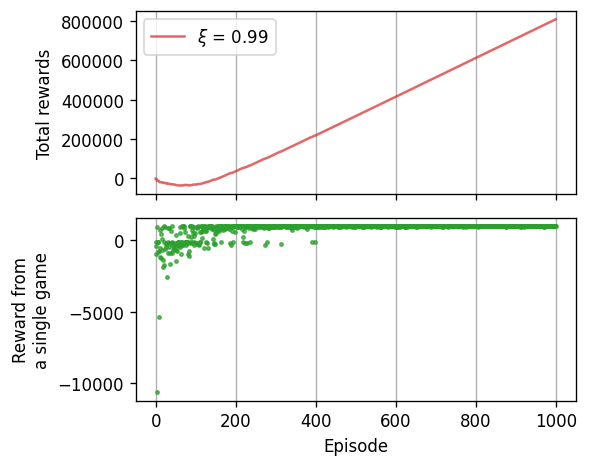

In [17]:
solver.plot_train_history(reward_history, total_reward_history)

In [18]:
# use a wrapper to create a human-renderable env from the original
human_env = HumanRendering(wrapped_env)

In [20]:
play_game(solver.agent, human_env, num_episodes=1)

--- Episode 1 Starting ---
Episode Finished. Num steps: 63; Total reward: 969.00
